In [30]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")


Libraries imported successfully!


In [31]:
# Define data path
data_path = Path("../data/softcite-extractions-oa-data/p01_one_percent_random_subset")

# Check if files exist
parquet_files = {
    'papers': data_path / 'papers.parquet',
    'mentions': data_path / 'mentions.pdf.parquet', 
    'purpose_assessments': data_path / 'purpose_assessments.pdf.parquet'
}

print("Checking for parquet files:")
for name, file_path in parquet_files.items():
    exists = file_path.exists()
    print(f"{name}: {file_path} - {'✓' if exists else '✗'}")
    
if all(f.exists() for f in parquet_files.values()):
    print("\nAll files found! Ready to load data.")
else:
    print("\nSome files are missing. Please check the data directory.")


Checking for parquet files:
papers: ../data/softcite-extractions-oa-data/p01_one_percent_random_subset/papers.parquet - ✓
mentions: ../data/softcite-extractions-oa-data/p01_one_percent_random_subset/mentions.pdf.parquet - ✓
purpose_assessments: ../data/softcite-extractions-oa-data/p01_one_percent_random_subset/purpose_assessments.pdf.parquet - ✓

All files found! Ready to load data.


In [32]:
# Load the parquet files
print("Loading parquet files...")

# Load papers data
papers_df = pd.read_parquet(parquet_files['papers'])
print(f"Papers dataset: {papers_df.shape[0]:,} rows, {papers_df.shape[1]} columns")

# Load mentions data  
mentions_df = pd.read_parquet(parquet_files['mentions'])
print(f"Mentions dataset: {mentions_df.shape[0]:,} rows, {mentions_df.shape[1]} columns")

# Load purpose assessments data
purpose_df = pd.read_parquet(parquet_files['purpose_assessments'])
print(f"Purpose assessments dataset: {purpose_df.shape[0]:,} rows, {purpose_df.shape[1]} columns")

print("\nData loaded successfully!")


Loading parquet files...
Papers dataset: 64,141 rows, 13 columns
Mentions dataset: 544,378 rows, 15 columns
Purpose assessments dataset: 3,266,268 rows, 7 columns

Data loaded successfully!


# Look at the initial heads for the dataframes


In [ ]:
papers_df.head()

,paper_id,softcite_id,title,published_year,published_date,publication_venue,publisher_name,doi,pmcid,pmid,genre,license_type,has_mentions
0,187,000084f1-f92a-4c64-b7f9-88d016af01db,Internists' attitudes towards terminal sedatio...,2004,2004-10-01,Journal of Medical Ethics,BMJ,10.1136/jme.2003.004895,PMC1733924,15467087,journal-article,,True
1,755,0002247c-6382-486e-8d6a-853eaf2901b2,Non-suicidal self-injuries in a sample of Mexi...,2017,2017-09-01,Salud mental,Instituto Nacional de Psiquiatria Ramon de la ...,10.17711/sm.0185-3325.2017.025,,,journal-article,,True
2,782,000235a5-bd2c-4ec8-a7c5-59072c3dc898,Incident preclinical mobility disability (PCMD...,2012,2012-05-01,Archives of Gerontology and Geriatrics,Elsevier BV,10.1016/j.archger.2011.08.018,PMC3248983,21944428,journal-article,,True
3,938,0002991f-63e2-4102-890c-8d692f98af62,"Cortisol concentration, pain and sedation scal...",2017,2017-08-01,Veterinary World,Veterinary World,10.14202/vetworld.2017.888-894,PMC5591474,28919678,journal-article,CC BY,True
4,1783,00050dbf-abf6-4a85-9a73-3372ea6077fe,Measuring Indirect Effects of Unfair Employer ...,2017,2017-01-01,SSRN Electronic Journal,Elsevier BV,10.2139/ssrn.3066713,,,journal-article,,True


In [34]:
mentions_df.head()

,software_mention_id,paper_id,source_file_type,mention_index,software_raw,software_normalized,version_raw,version_normalized,publisher_raw,publisher_normalized,language_raw,language_normalized,url_raw,url_normalized,context_full_text
0,187.pdf.00000,187,pdf,0,Epi Info,Epi Info,6,6,Centers for Disease Control and Prevention,Centers for Disease Control and Prevention,,,,,"Frequencies, x 2 analyses, and multivariable l..."
1,187.pdf.00001,187,pdf,1,SAS,SAS,8,8,SAS Institute Inc,SAS Institute Inc,,,,,"Frequencies, x 2 analyses, and multivariable l..."
2,755.pdf.00000,755,pdf,0,SPSS,SPSS,22,22,SPSS Inc,SPSS Inc,,,,,All analyses were conducted with SPSS software...
3,782.pdf.00000,782,pdf,0,Stata,Stata,,,Statacorp,Statacorp,,,,,"Stata statistical software (Statacorp, College..."
4,938.pdf.00000,938,pdf,0,GraphPad Prism,GraphPad Prism,5.0,5.0,,,,,,,Data were statistically processed and analyzed...


In [51]:
purpose_df.head(20)

,software_mention_id,paper_id,source_file_type,mention_index,scope,purpose,certainty_score
0,187.pdf.00000,187,pdf,0,document,created,5.364418e-06
1,187.pdf.00000,187,pdf,0,document,shared,1.192093e-07
2,187.pdf.00000,187,pdf,0,document,used,9.999933e-01
3,187.pdf.00000,187,pdf,0,local,created,5.364418e-06
4,187.pdf.00000,187,pdf,0,local,shared,1.192093e-07
5,187.pdf.00000,187,pdf,0,local,used,9.999933e-01
6,187.pdf.00001,187,pdf,1,document,created,5.364418e-06
7,187.pdf.00001,187,pdf,1,document,shared,1.192093e-07
8,187.pdf.00001,187,pdf,1,document,used,9.999933e-01
9,187.pdf.00001,187,pdf,1,local,created,5.364418e-06


In [35]:
unique_software_mentions = mentions_df['software_normalized'].value_counts()
unique_software_mentions.head(20)


LaTeX              20049
SPSS               15850
MATLAB              6126
ImageJ              4997
SAS                 4863
Excel               4622
GraphPad Prism      4183
code                4167
Matlab              3750
Android             3044
survival            2700
Stata               2536
script              2339
BLAST               2329
Google              2293
Linux               2135
scripts             1642
software            1437
SPSS Statistics     1395
Google Scholar      1363
Name: software_normalized, dtype: int64

## Software Mentions Analysis by Paper

Let's analyze software mentions grouped by paper_id and find where specific software is mentioned most frequently.


In [36]:
# Group software mentions by paper_id
print("=== SOFTWARE MENTIONS BY PAPER ===")

# Count mentions per paper
mentions_per_paper = mentions_df.groupby('paper_id').size().reset_index(name='mention_count')
print(f"Number of papers with software mentions: {len(mentions_per_paper):,}")

# Show distribution of mentions per paper
print(f"\nMention count statistics:")
print(mentions_per_paper['mention_count'].describe())

# Show papers with most mentions
print(f"\nTop 10 papers by mention count:")
top_papers = mentions_per_paper.nlargest(10, 'mention_count')
print(top_papers)


=== SOFTWARE MENTIONS BY PAPER ===
Number of papers with software mentions: 64,141

Mention count statistics:
count    64141.000000
mean         8.487208
std         31.227452
min          1.000000
25%          1.000000
50%          2.000000
75%          6.000000
max       4607.000000
Name: mention_count, dtype: float64

Top 10 papers by mention count:
       paper_id  mention_count
20115   7491989           4607
56912  21068065           1365
52322  19357132           1273
31901  11828498           1068
18728   6963351            915
27606  10220302            876
10993   4062782            844
24003   8894786            801
52469  19407776            752
20497   7630708            717


In [ ]:
# Find the specific paper that mentions the most software
most_mentioned_paper = papers_df[papers_df['paper_id'] == 7491989]
columns_to_view = ['title', 'doi']
print(most_mentioned_paper[columns_to_view])    

                                                title  \
20115  Multi-Order Networks for Action Unit Detection   

                              doi  
20115  10.1109/taffc.2022.3178524  


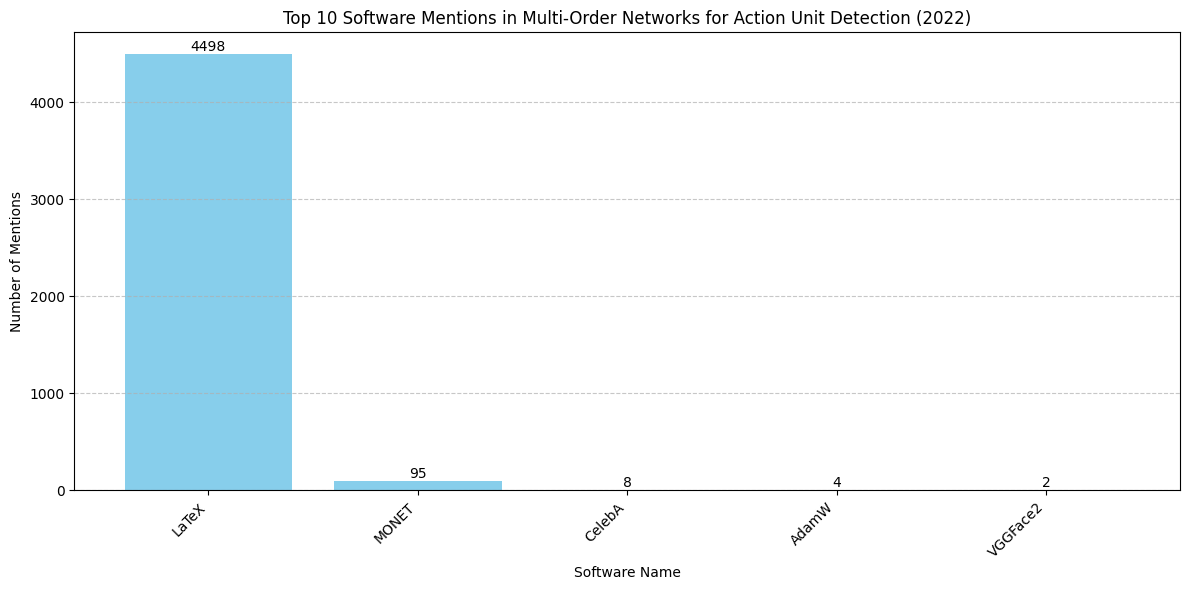

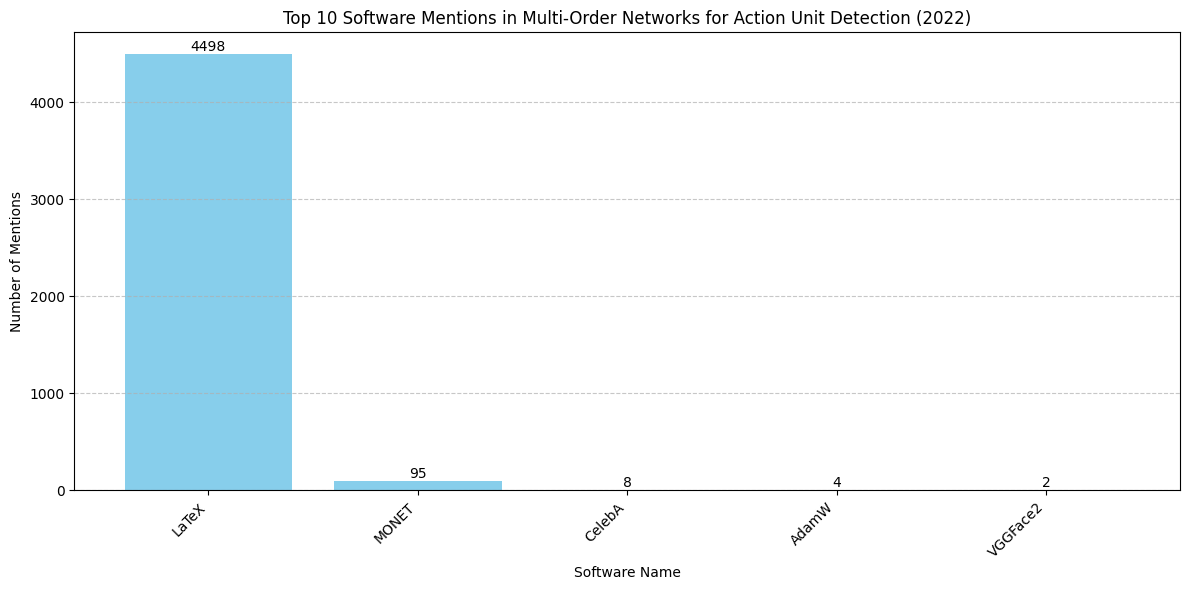

In [ ]:
def plot_software_mentions_for_paper(paper_id, top_n=10, figsize=(12, 6), color='skyblue'):
    """
    Create a bar chart showing the top software mentions for a specific paper.
    
    Parameters:
    -----------
    paper_id : int
        The paper ID to analyze
    top_n : int, default 10
        Number of top software to display
    figsize : tuple, default (12, 6)
        Figure size for the plot
    color : str, default 'skyblue'
        Color for the bars
    
    Returns:
    --------
    matplotlib.figure.Figure
        The created figure object
    """
    # Get the paper info
    paper_info = papers_df[papers_df['paper_id'] == paper_id]
    if len(paper_info) == 0:
        print(f"No paper found with ID {paper_id}")
        return None
    
    # Get software mentions for this paper
    paper_mentions = mentions_df[mentions_df['paper_id'] == paper_id]
    if len(paper_mentions) == 0:
        print(f"No software mentions found for paper {paper_id}")
        return None
    
    # Count mentions by software
    mention_counts = paper_mentions['software_normalized'].value_counts()
    
    # Get top N software
    top_n_mentions = mention_counts.head(top_n)
    
    # Convert to DataFrame for plotting
    plot_df = top_n_mentions.reset_index()
    plot_df.columns = ['Software', 'Mentions']
    
    # Create the plot
    plt.figure(figsize=figsize)
    bars = plt.bar(plot_df['Software'], plot_df['Mentions'], color=color)
    
    # Add labels and title
    paper_title = paper_info['title'].iloc[0] if 'title' in paper_info.columns else f"Paper {paper_id}"
    plt.title(f'Top {top_n} Software Mentions in {paper_title} ({paper_info["published_year"].iloc[0]})') 
    plt.xlabel('Software Name')
    plt.ylabel('Number of Mentions')
    
    # Rotate x-axis labels
    plt.xticks(rotation=45, ha='right')
    
    # Add value labels on bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, 
                 int(yval), ha='center', va='bottom', fontsize=10)
    
    # Add grid and adjust layout
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    
    return plt.gcf()

# Usage examples:
# Plot for paper 7491989
plot_software_mentions_for_paper(7491989)


# The paper that has the most mentions of software overall is called "Multi-Order Networks for Action Unit Detection" by 

In [53]:
# Find most frequently mentioned software
print("=== MOST FREQUENTLY MENTIONED SOFTWARE ===")

# Count mentions by software (using normalized names for cleaner results)
software_counts = mentions_df['software_normalized'].value_counts().head(20)
print("Top 20 most mentioned software:")
print(software_counts)

# Also show raw software names for comparison
print(f"\nTop 10 raw software names:")
raw_software_counts = mentions_df['software_raw'].value_counts().head(10)
print(raw_software_counts)


=== MOST FREQUENTLY MENTIONED SOFTWARE ===
Top 20 most mentioned software:
LaTeX              20049
SPSS               15850
MATLAB              6126
ImageJ              4997
SAS                 4863
Excel               4622
GraphPad Prism      4183
code                4167
Matlab              3750
Android             3044
survival            2700
Stata               2536
script              2339
BLAST               2329
Google              2293
Linux               2135
scripts             1642
software            1437
SPSS Statistics     1395
Google Scholar      1363
Name: software_normalized, dtype: int64

Top 10 raw software names:
LaTeX             20049
SPSS              15845
MATLAB             6112
ImageJ             4991
SAS                4860
Excel              4618
code               4167
GraphPad Prism     4006
Matlab             3745
Android            3042
Name: software_raw, dtype: int64


In [55]:
# Function to analyze specific software mentions
def analyze_software_mentions(software_name, use_normalized=True):
    """
    Analyze mentions of a specific software across papers
    """
    if use_normalized:
        software_mentions = mentions_df[mentions_df['software_normalized'] == software_name]
    else:
        software_mentions = mentions_df[mentions_df['software_raw'] == software_name]
    
    if len(software_mentions) == 0:
        print(f"No mentions found for '{software_name}'")
        return None
    
    # Count mentions per paper for this software
    mentions_by_paper = software_mentions.groupby('paper_id').size().reset_index(name='mention_count')
    
    print(f"=== ANALYSIS FOR '{software_name}' ===")
    print(f"Total mentions: {len(software_mentions):,}")
    print(f"Number of papers mentioning it: {len(mentions_by_paper):,}")
    print(f"Average mentions per paper: {mentions_by_paper['mention_count'].mean():.2f}")
    print(f"Max mentions in a single paper: {mentions_by_paper['mention_count'].max()}")
    
    # Show papers with most mentions of this software
    print(f"\nPapers with most mentions of '{software_name}':")
    top_papers = mentions_by_paper.nlargest(10, 'mention_count')
    print(top_papers)
    
    return mentions_by_paper

# Run Example of function
example_analysis = analyze_software_mentions('LaTeX')


=== ANALYSIS FOR 'LaTeX' ===
Total mentions: 20,049
Number of papers mentioning it: 211
Average mentions per paper: 95.02
Max mentions in a single paper: 4498

Papers with most mentions of 'LaTeX':
     paper_id  mention_count
64    7491989           4498
59    6963351            915
42    4946447            669
171  18618787            639
11    1878645            605
206  22936409            549
110  11955186            502
79    8894786            462
56    6788424            438
77    8811416            417


## Joining Mentions with Purpose Assessments

Now let's join the mentions data with purpose assessments to analyze how software is being used in papers. The purpose assessments tell us whether software was "used", "created", or "shared" in the research, with certainty scores.


In [58]:
# Join mentions with purpose assessments
print("=== JOINING MENTIONS WITH PURPOSE ASSESSMENTS ===")

# Left join mentions with purpose assessments on software_mention_id
mentions_with_purpose = pd.merge(
    mentions_df, 
    purpose_df, 
    on='software_mention_id', 
    how='left'
)

print(f"Joined dataset shape: {mentions_with_purpose.shape}")
print(f"Original mentions: {mentions_df.shape[0]:,}")
print(f"Purpose assessments: {purpose_df.shape[0]:,}")
print(f"Joined mentions with purpose: {mentions_with_purpose.shape[0]:,}")

# Show the new columns from purpose assessments
purpose_columns = [col for col in purpose_df.columns if col != 'software_mention_id']
print(f"\nNew columns from purpose assessments: {purpose_columns}")

# Show sample of joined data
print(mentions_with_purpose.head(10))


=== JOINING MENTIONS WITH PURPOSE ASSESSMENTS ===
Joined dataset shape: (3266268, 21)
Original mentions: 544,378
Purpose assessments: 3,266,268
Joined mentions with purpose: 3,266,268

New columns from purpose assessments: ['paper_id', 'source_file_type', 'mention_index', 'scope', 'purpose', 'certainty_score']
    software_mention_id  paper_id_x source_file_type_x  mention_index_x  \
0         187.pdf.00000         187                pdf                0   
1         187.pdf.00000         187                pdf                0   
2         187.pdf.00000         187                pdf                0   
3         187.pdf.00000         187                pdf                0   
4         187.pdf.00000         187                pdf                0   
5         187.pdf.00000         187                pdf                0   
6         187.pdf.00001         187                pdf                1   
7         187.pdf.00001         187                pdf                1   
8         187

In [61]:
# Filter for specific paper (paper_id 7491989)
print("=== ANALYSIS FOR PAPER ID 7491989 ===")

# Filter joined data for the specific paper
paper_7491989 = mentions_with_purpose[mentions_with_purpose['software_mention_id'] == 7491989]

if len(paper_7491989) > 0:
    print(f"Found {len(paper_7491989):,} mentions with purpose assessments for paper 7491989")
    
    # Show software mentions in this paper with their purpose assessments
    print(f"\nSoftware mentions in paper 7491989:")
    key_columns = ['software_normalized', 'software_raw', 'purpose', 'scope', 'certainty_score']
    print(paper_7491989[key_columns].head(15))
    
    # Count unique software mentioned in this paper
    unique_software = paper_7491989['software_normalized'].nunique()
    print(f"\nNumber of unique software mentioned: {unique_software}")
    
else:
    print("No mentions found for paper_id 7491989")
    print("Let's check what paper_ids are available:")
    available_papers = mentions_with_purpose['software_mention_id'].unique()[:10]
    print(f"Sample paper_ids: {available_papers}")


=== ANALYSIS FOR PAPER ID 7491989 ===
No mentions found for paper_id 7491989
Let's check what paper_ids are available:
Sample paper_ids: ['       187.pdf.00000' '       187.pdf.00001' '       755.pdf.00000'
 '       782.pdf.00000' '       938.pdf.00000' '       938.pdf.00001'
 '      1783.pdf.00000' '      1856.pdf.00000' '      1856.pdf.00001'
 '      1856.pdf.00002']


In [ ]:
# Analyze purpose assessments for the specific paper
if len(paper_7491989) > 0:
    print("=== PURPOSE ASSESSMENT ANALYSIS FOR PAPER 7491989 ===")
    
    # Count mentions by purpose type
    print("Mentions by purpose type:")
    purpose_counts = paper_7491989['purpose'].value_counts()
    print(purpose_counts)
    
    # Count mentions by scope (document vs mention level)
    print(f"\nMentions by scope:")
    scope_counts = paper_7491989['scope'].value_counts()
    print(scope_counts)
    
    # Show software with high "used" scores (certainty > 0.5)
    high_used_scores = paper_7491989[
        (paper_7491989['purpose'] == 'used') & 
        (paper_7491989['certainty_score'] > 0.5)
    ]
    
    print(f"\nSoftware with high 'used' scores (>0.5):")
    if len(high_used_scores) > 0:
        used_software = high_used_scores[['software_normalized', 'certainty_score', 'scope']].drop_duplicates()
        print(used_software.sort_values('certainty_score', ascending=False))
    else:
        print("No software with high 'used' scores found")
    
    # Show software with high "created" scores
    high_created_scores = paper_7491989[
        (paper_7491989['purpose'] == 'created') & 
        (paper_7491989['certainty_score'] > 0.5)
    ]
    
    print(f"\nSoftware with high 'created' scores (>0.5):")
    if len(high_created_scores) > 0:
        created_software = high_created_scores[['software_normalized', 'certainty_score', 'scope']].drop_duplicates()
        print(created_software.sort_values('certainty_score', ascending=False))
    else:
        print("No software with high 'created' scores found")


In [ ]:
# Compare document-level vs mention-level purpose assessments
if len(paper_7491989) > 0:
    print("=== DOCUMENT vs MENTION LEVEL COMPARISON ===")
    
    # Create a comparison of document vs mention level assessments
    comparison_data = []
    
    for software in paper_7491989['software_normalized'].unique():
        software_data = paper_7491989[paper_7491989['software_normalized'] == software]
        
        # Get document-level scores
        doc_scores = software_data[software_data['scope'] == 'document']
        # Get mention-level scores  
        mention_scores = software_data[software_data['scope'] == 'mention']
        
        if len(doc_scores) > 0 and len(mention_scores) > 0:
            for purpose in ['used', 'created', 'shared']:
                doc_score = doc_scores[doc_scores['purpose'] == purpose]['certainty_score'].iloc[0] if len(doc_scores[doc_scores['purpose'] == purpose]) > 0 else 0
                mention_score = mention_scores[mention_scores['purpose'] == purpose]['certainty_score'].iloc[0] if len(mention_scores[mention_scores['purpose'] == purpose]) > 0 else 0
                
                comparison_data.append({
                    'software': software,
                    'purpose': purpose,
                    'document_score': doc_score,
                    'mention_score': mention_score,
                    'difference': doc_score - mention_score
                })
    
    if comparison_data:
        comparison_df = pd.DataFrame(comparison_data)
        print("Document vs Mention level score comparison:")
        print(comparison_df.head(10))
        
        # Show software with biggest differences
        print(f"\nSoftware with biggest document vs mention differences:")
        biggest_diffs = comparison_df.nlargest(5, 'difference')
        print(biggest_diffs[['software', 'purpose', 'document_score', 'mention_score', 'difference']])


In [ ]:
# Interactive analysis - you can change the software name here
# Try different software names to see their mention patterns

# Example analyses for different software
software_to_analyze = ['SPSS', 'Excel', 'ImageJ', 'R', 'Python']

for software in software_to_analyze:
    print(f"\n{'='*50}")
    analyze_software_mentions(software)
    print(f"{'='*50}")


NameError: name 'software_counts' is not defined

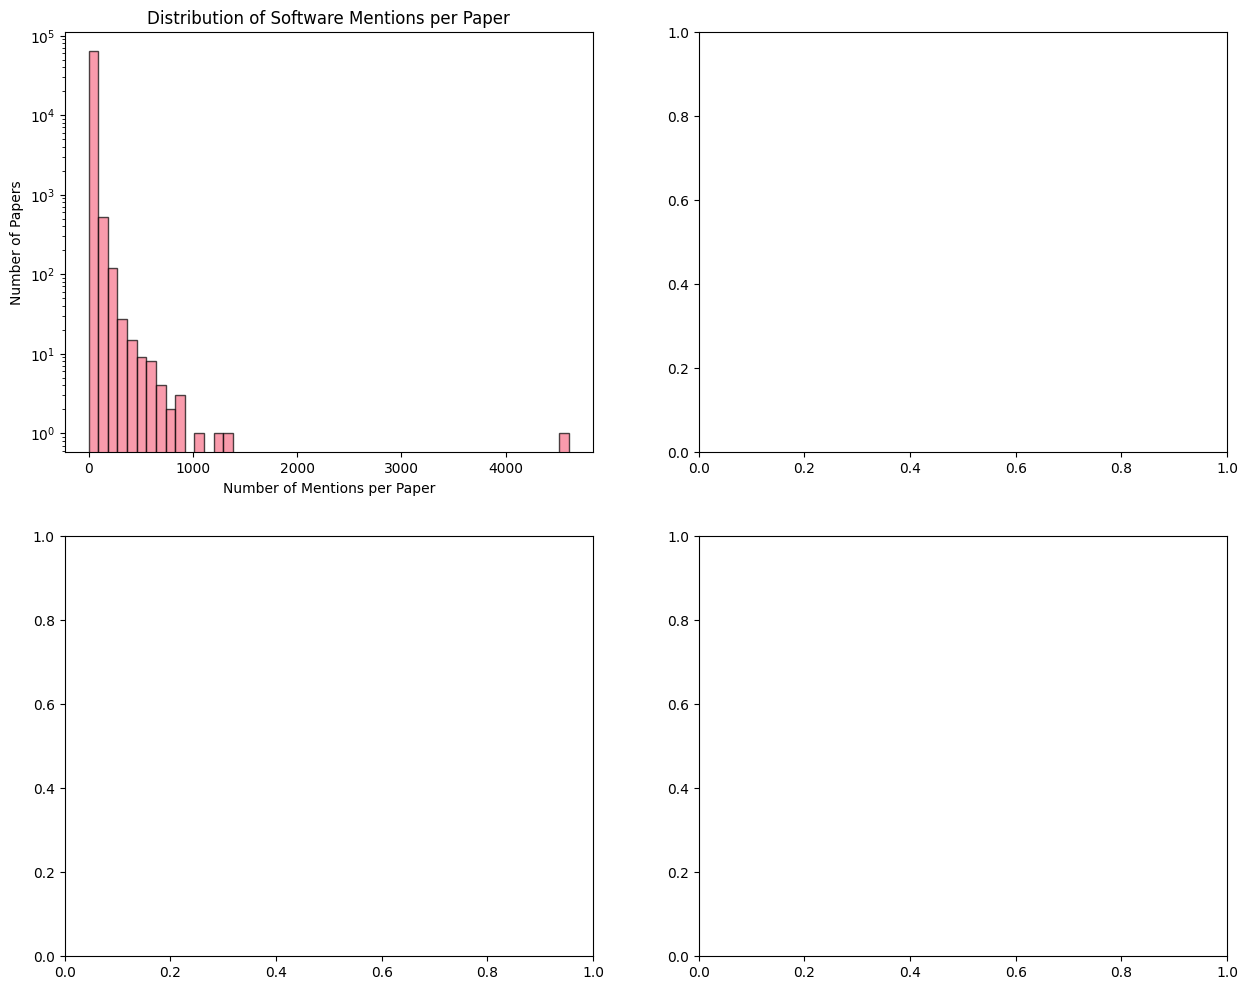

In [52]:
# Visualizations for software mention patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Distribution of mentions per paper
axes[0, 0].hist(mentions_per_paper['mention_count'], bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Number of Mentions per Paper')
axes[0, 0].set_ylabel('Number of Papers')
axes[0, 0].set_title('Distribution of Software Mentions per Paper')
axes[0, 0].set_yscale('log')

# 2. Top 15 most mentioned software
top_15_software = software_counts.head(15)
axes[0, 1].barh(range(len(top_15_software)), top_15_software.values)
axes[0, 1].set_yticks(range(len(top_15_software)))
axes[0, 1].set_yticklabels(top_15_software.index)
axes[0, 1].set_xlabel('Number of Mentions')
axes[0, 1].set_title('Top 15 Most Mentioned Software')

# 3. Papers with most mentions (top 20)
top_20_papers = mentions_per_paper.nlargest(20, 'mention_count')
axes[1, 0].bar(range(len(top_20_papers)), top_20_papers['mention_count'])
axes[1, 0].set_xlabel('Paper Rank')
axes[1, 0].set_ylabel('Number of Mentions')
axes[1, 0].set_title('Top 20 Papers by Mention Count')

# 4. Software diversity per paper (if we have enough data)
if len(mentions_per_paper) > 0:
    # Calculate unique software per paper
    unique_software_per_paper = mentions_df.groupby('paper_id')['software_normalized'].nunique().reset_index(name='unique_software_count')
    axes[1, 1].hist(unique_software_per_paper['unique_software_count'], bins=30, alpha=0.7, edgecolor='black')
    axes[1, 1].set_xlabel('Number of Unique Software per Paper')
    axes[1, 1].set_ylabel('Number of Papers')
    axes[1, 1].set_title('Distribution of Software Diversity per Paper')

plt.tight_layout()
plt.show()


## Custom Analysis

You can now easily analyze any specific software by modifying the code below:


In [ ]:
# CUSTOM ANALYSIS - Change the software name here to analyze any software
# You can use either normalized names (recommended) or raw names

# Example: Analyze a specific software
software_name = "R"  # Change this to any software you want to analyze
use_normalized = True  # Set to False to use raw software names

# Run the analysis
result = analyze_software_mentions(software_name, use_normalized)

# If you want to see the actual papers that mention this software most:
if result is not None:
    print(f"\nDetailed breakdown for '{software_name}':")
    print("Papers with most mentions:")
    print(result.nlargest(10, 'mention_count'))
